# SpaceNet — Large Building Detection (>1000 m²)
**Cities:** Paris + Las Vegas · **Model:** EfficientNet-B0 U-Net

**How area is calculated:** Model detects ALL buildings → binary mask → watershed splits touching buildings into individual instances → each instance polygon is vectorized → reprojected to UTM (metres) → area calculated from pixel count in metric CRS → only buildings >1000 m² are kept.

## 1. Imports

In [3]:
import rasterio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from tqdm import tqdm
from rasterio.features import rasterize, shapes
from rasterio.transform import from_bounds
import segmentation_models_pytorch as smp
import pytorch_lightning as pl
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from shapely.geometry import shape
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd
import json
import glob
import warnings
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.morphology import remove_small_objects, erosion, disk


## 2. Paths & constants

In [4]:
# ── Paris paths ──────────────────────────────────────────────────────
PARIS_ROOT     = Path("dataset/AOI_3_Paris_Train/AOI_3_Paris_Train")
PARIS_IMG_DIR  = PARIS_ROOT / "RGB-PanSharpen"
PARIS_GEO_DIR  = PARIS_ROOT / "geojson/buildings"
PARIS_MASK_ALL = PARIS_ROOT / "masks_all"
PARIS_MASK_LRG = PARIS_ROOT / "masks"

# ── Vegas paths ───────────────────────────────────────────────────────
# After extracting SN2_buildings_train_AOI_2_Vegas.tar.gz:
VEGAS_ROOT     = Path("dataset/AOI_2_Vegas_Train")
VEGAS_IMG_DIR  = VEGAS_ROOT / "RGB-PanSharpen"
VEGAS_GEO_DIR  = VEGAS_ROOT / "geojson/buildings"
VEGAS_MASK_ALL = VEGAS_ROOT / "masks_all"
VEGAS_MASK_LRG = VEGAS_ROOT / "masks"

# Create mask directories
for d in [PARIS_MASK_ALL, PARIS_MASK_LRG, VEGAS_MASK_ALL, VEGAS_MASK_LRG]:
    d.mkdir(parents=True, exist_ok=True)

METRIC_CRS  = "EPSG:32631"   # UTM zone 31N — covers both Paris and Vegas
MIN_AREA_M2 = 1000           # minimum building area in square metres
THRESHOLD   = 0.45

print("Paris images :", len(list(PARIS_IMG_DIR.glob("*.tif"))))
print("Vegas images :", len(list(VEGAS_IMG_DIR.glob("*.tif"))))


Paris images : 1148
Vegas images : 3851


## 3. Extract Vegas dataset
Run this once to extract the tarball if not already done.

In [3]:
import tarfile

vegas_tar = Path("dataset/SN2_buildings_train_AOI_2_Vegas.tar.gz")

if vegas_tar.exists() and not VEGAS_ROOT.exists():
    print("Extracting Vegas dataset...")
    with tarfile.open(vegas_tar) as tar:
        tar.extractall(path="dataset/")
    print("Done.")
elif VEGAS_ROOT.exists():
    print(f"Vegas already extracted at {VEGAS_ROOT}")
    print(f"Images: {len(list(VEGAS_IMG_DIR.glob('*.tif')))}")
    print(f"GeoJSONs: {len(list(VEGAS_GEO_DIR.glob('*.geojson')))}")
else:
    print("WARNING: tarball not found at", vegas_tar)
    print("Check the exact path — the tar.gz should be in dataset/")


Vegas already extracted at dataset/SN2_buildings_train_AOI_2_Vegas/AOI_2_Vegas_Train
Images: 0
GeoJSONs: 0


## 4. Visualisation helper

In [5]:
def stretch(img):
    """Percentile stretch per band — removes black borders and washed-out look."""
    out = np.zeros_like(img, dtype=np.float32)
    for i in range(3):
        band = img[:, :, i]
        valid = band[band > 0]
        if len(valid) == 0:
            continue
        lo = np.percentile(valid, 2)
        hi = np.percentile(valid, 98)
        out[:, :, i] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return out


## 5. Mask generation (reusable for any city)

**How area filtering works here (for `masks` folder):**
GeoJSON polygons → reproject to UTM → `area = polygon.area` in m² → keep only if >1000 m² → rasterize to pixel mask.

**The `masks_all` folder** stores ALL buildings with no filter — used for training so the model learns what every building looks like.

In [7]:
def build_masks_for_city(img_dir, geo_dir, mask_all_dir, mask_lrg_dir,
                          city_name, metric_crs=METRIC_CRS,
                          min_area=MIN_AREA_M2):
    """
    Generate both mask types for a city:
      masks_all/ — every building (used for training)
      masks/     — only buildings >min_area m² (ground truth for evaluation)

    Area calculation:
      GeoJSON (EPSG:4326 degrees) → reproject to UTM (metres)
      → shapely .area gives m² → filter >1000 m²
    """
    mask_all_dir.mkdir(parents=True, exist_ok=True)
    mask_lrg_dir.mkdir(parents=True, exist_ok=True)

    img_paths = sorted(img_dir.glob("*.tif"))
    geo_paths = sorted(geo_dir.glob("*.geojson"))
    geo_lookup = {g.stem.split("_")[-1]: g for g in geo_paths}

    n_all = n_large = n_skip = 0

    for img_path in tqdm(img_paths, desc=f"{city_name} masks"):
        key = img_path.stem.split("_")[-1]
        if key not in geo_lookup:
            n_skip += 1
            continue

        geo_path = geo_lookup[key]
        out_all  = mask_all_dir / f"mask_{key}.tif"
        out_lrg  = mask_lrg_dir / f"mask_{key}.tif"

        # Skip if both masks already exist
        if out_all.exists() and out_lrg.exists():
            continue

        with rasterio.open(img_path) as src:
            meta          = src.meta.copy()
            img_crs       = src.crs
            img_transform = src.transform
            h, w          = src.height, src.width

        meta.update(count=1, dtype="uint8", compress="lzw")

        gdf = gpd.read_file(geo_path)

        if gdf.empty or gdf.geometry.isna().all():
            # No buildings — write blank masks
            blank = np.zeros((h, w), dtype=np.uint8)
            for out_path in [out_all, out_lrg]:
                with rasterio.open(out_path, "w", **meta) as dst:
                    dst.write(blank, 1)
            continue

        # Align CRS to image
        if gdf.crs != img_crs:
            gdf = gdf.to_crs(img_crs)

        # Fix invalid geometries
        gdf["geometry"] = gdf.geometry.buffer(0)
        gdf = gdf[gdf.geometry.is_valid & gdf.geometry.notna()].copy()

        # ── AREA CALCULATION ────────────────────────────────────────
        # Reproject to metric UTM to get area in m²
        # This is the ONLY place area is computed from ground truth
        gdf_utm        = gdf.to_crs(metric_crs)
        gdf["area_m2"] = gdf_utm.geometry.area   # m²
        # ────────────────────────────────────────────────────────────

        # All-buildings mask
        if not out_all.exists():
            shapes_all = [(g.__geo_interface__, 1) for g in gdf.geometry]
            mask_all   = rasterize(shapes_all, out_shape=(h, w),
                                   transform=img_transform, fill=0,
                                   dtype=np.uint8, all_touched=True)
            with rasterio.open(out_all, "w", **meta) as dst:
                dst.write(mask_all, 1)
            if mask_all.max() == 1:
                n_all += 1

        # Large-buildings mask (>min_area m²)
        if not out_lrg.exists():
            large = gdf[gdf["area_m2"] > min_area]
            if large.empty:
                mask_lrg = np.zeros((h, w), dtype=np.uint8)
            else:
                shapes_lrg = [(g.__geo_interface__, 1) for g in large.geometry]
                mask_lrg   = rasterize(shapes_lrg, out_shape=(h, w),
                                       transform=img_transform, fill=0,
                                       dtype=np.uint8, all_touched=True)
            with rasterio.open(out_lrg, "w", **meta) as dst:
                dst.write(mask_lrg, 1)
            if mask_lrg.max() == 1:
                n_large += 1

    print(f"{city_name}: tiles_with_any_bld={n_all} "
          f"tiles_with_large_bld={n_large} "
          f"skipped={n_skip}")


# Generate masks for BOTH cities
build_masks_for_city(PARIS_IMG_DIR, PARIS_GEO_DIR,
                     PARIS_MASK_ALL, PARIS_MASK_LRG, "Paris")

build_masks_for_city(VEGAS_IMG_DIR, VEGAS_GEO_DIR,
                     VEGAS_MASK_ALL, VEGAS_MASK_LRG, "Vegas")


Paris masks: 100%|██████████| 1148/1148 [00:00<00:00, 23717.06it/s]


Paris: tiles_with_any_bld=0 tiles_with_large_bld=0 skipped=0


Vegas masks: 100%|██████████| 3851/3851 [00:00<00:00, 29269.14it/s]

Vegas: tiles_with_any_bld=0 tiles_with_large_bld=0 skipped=0


## 6. Build combined tile index (Paris + Vegas)

In [8]:
COMBINED_CACHE = Path("dataset/combined_tile_index.json")

def build_tile_index(img_dir, mask_all_dir):
    """Scan masks_all and pair with images. Returns (img_paths, mask_paths, has_building)."""
    imgs, masks, has_bld = [], [], []
    for mask_path in sorted(mask_all_dir.glob("*.tif")):
        key     = mask_path.stem.replace("mask_", "")
        matches = list(img_dir.glob(f"*{key}.tif"))
        if not matches:
            continue
        with rasterio.open(mask_path) as src:
            has = int(src.read(1).max() == 1)
        imgs.append(matches[0])
        masks.append(mask_path)
        has_bld.append(has)
    return imgs, masks, has_bld


if COMBINED_CACHE.exists():
    print("Loading combined index from cache...")
    with open(COMBINED_CACHE) as f:
        index = json.load(f)
else:
    print("Building combined tile index...")
    paris_imgs, paris_masks, paris_has = build_tile_index(
        PARIS_IMG_DIR, PARIS_MASK_ALL)
    vegas_imgs, vegas_masks, vegas_has = build_tile_index(
        VEGAS_IMG_DIR, VEGAS_MASK_ALL)

    all_imgs_list  = paris_imgs  + vegas_imgs
    all_masks_list = paris_masks + vegas_masks
    all_has        = paris_has   + vegas_has

    index = {
        "img_paths"   : [str(p) for p in all_imgs_list],
        "mask_paths"  : [str(p) for p in all_masks_list],
        "has_building": all_has,
    }
    with open(COMBINED_CACHE, "w") as f:
        json.dump(index, f)
    print(f"Paris : {len(paris_imgs)} tiles ({sum(paris_has)} with buildings)")
    print(f"Vegas : {len(vegas_imgs)} tiles ({sum(vegas_has)} with buildings)")

all_imgs     = [Path(p) for p in index["img_paths"]]
all_masks    = [Path(p) for p in index["mask_paths"]]
has_building = index["has_building"]

print(f"\nCombined total : {len(all_imgs)} tiles")
print(f"With buildings : {sum(has_building)}")


Loading combined index from cache...

Combined total : 1148 tiles
With buildings : 633


## 7. Train / val split

In [9]:
(train_imgs, val_imgs,
 train_masks, val_masks,
 train_has, val_has) = train_test_split(
    all_imgs, all_masks, has_building,
    test_size=0.15, random_state=42
)
print(f"Train: {len(train_imgs)} tiles ({sum(train_has)} with buildings)")
print(f"Val  : {len(val_imgs)}   tiles ({sum(val_has)}  with buildings)")


Train: 975 tiles (534 with buildings)
Val  : 173   tiles (99  with buildings)


## 8. Normalisation

In [10]:
def load_and_normalize(img_path):
    """
    Per-image percentile stretch.
    Used in BOTH training and inference — ensures consistency.
    """
    with rasterio.open(img_path) as src:
        raw = src.read([1, 2, 3]).transpose(1, 2, 0).astype(np.float32)
    img = np.zeros_like(raw)
    for i in range(3):
        band  = raw[:, :, i]
        valid = band[band > 0]
        if len(valid) == 0:
            continue
        lo = np.percentile(valid, 2)
        hi = np.percentile(valid, 98)
        img[:, :, i] = np.clip((band - lo) / (hi - lo + 1e-6), 0, 1)
    return img.astype(np.float32)


## 9. Dataset

In [11]:
class BuildingDataset(Dataset):
    def __init__(self, img_paths, mask_paths, has_building,
                 patch=384, augment=True):
        self.pairs        = list(zip(img_paths, mask_paths))
        self.has_building = has_building
        self.augment      = augment
        self.patch        = patch
        self.tfm          = self._make_transform(augment)

    def _make_transform(self, augment):
        shared = [ToTensorV2()]
        if augment:
            return A.Compose([
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                A.Transpose(p=0.3),
                A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15,
                                   rotate_limit=30, p=0.5, border_mode=0),
                A.ColorJitter(brightness=0.3, contrast=0.3,
                              saturation=0.2, hue=0.05, p=0.5),
                A.GaussNoise(p=0.2),
            ] + shared)
        return A.Compose(shared)

    def _smart_crop(self, img, mask):
        """70% chance of cropping centred on a building pixel."""
        p      = self.patch
        H, W   = mask.shape
        ys, xs = np.where(mask > 0)
        if len(ys) > 0 and np.random.rand() < 0.7:
            idx = np.random.randint(len(ys))
            cy, cx = ys[idx], xs[idx]
            y1 = int(np.clip(cy - p // 2, 0, H - p))
            x1 = int(np.clip(cx - p // 2, 0, W - p))
        else:
            y1 = np.random.randint(0, max(1, H - p))
            x1 = np.random.randint(0, max(1, W - p))
        return img[y1:y1+p, x1:x1+p], mask[y1:y1+p, x1:x1+p]

    def get_sampler_weights(self):
        weights = [3.0 if h else 1.0 for h in self.has_building]
        return torch.tensor(weights, dtype=torch.float)

    def __len__(self):
        return len(self.pairs) * (6 if self.augment else 2)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx % len(self.pairs)]
        img  = load_and_normalize(img_path)
        with rasterio.open(mask_path) as src:
            mask = src.read(1).astype(np.float32)
        img, mask = self._smart_crop(img, mask)
        out = self.tfm(image=img, mask=mask)
        return out["image"], out["mask"].unsqueeze(0)


## 10. Model (EfficientNet-B0 U-Net)

In [12]:
class BuildingModel(pl.LightningModule):
    def __init__(self, lr=1e-3, pos_weight=3.0):
        super().__init__()
        self.save_hyperparameters()
        self.net = smp.Unet(
            encoder_name    = "efficientnet-b0",
            encoder_weights = "imagenet",
            in_channels     = 3,
            classes         = 1,
            activation      = None,
        )
        self.dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
        self.bce  = smp.losses.SoftBCEWithLogitsLoss(
            pos_weight=torch.tensor([pos_weight])
        )

    def forward(self, x):
        return self.net(x)

    def _step(self, batch, stage):
        imgs, masks = batch
        logits = self(imgs)
        loss   = self.dice(logits, masks) + self.bce(logits, masks)
        preds  = (logits.sigmoid() > 0.5).long()
        tp, fp, fn, tn = smp.metrics.get_stats(
            preds, masks.long(), mode="binary", threshold=None
        )
        iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro-imagewise")
        f1  = smp.metrics.f1_score( tp, fp, fn, tn, reduction="micro-imagewise")
        self.log(f"{stage}_loss", loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_iou",  iou,  prog_bar=True, on_step=False, on_epoch=True)
        self.log(f"{stage}_f1",   f1,   prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def training_step(self, batch, _):   return self._step(batch, "train")
    def validation_step(self, batch, _): return self._step(batch, "val")

    def configure_optimizers(self):
        opt   = torch.optim.AdamW(self.parameters(), lr=self.hparams.lr, weight_decay=1e-4)
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=self.hparams.lr,
            total_steps=self.trainer.estimated_stepping_batches,
        )
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sched, "interval": "step"}}


## 11. Train on Paris + Vegas combined

In [20]:
STEPS_PER_EPOCH = 300   # more steps since we have ~5000 tiles now

train_ds = BuildingDataset(train_imgs, train_masks, train_has, patch=384, augment=True)
val_ds   = BuildingDataset(val_imgs,   val_masks,   val_has,   patch=384, augment=False)

print(f"Train samples : {len(train_ds)}")
print(f"Val samples   : {len(val_ds)}")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False,
                          num_workers=0, pin_memory=False)

model = BuildingModel(lr=1e-3, pos_weight=3.0)

trainer = pl.Trainer(
    max_epochs          = 60,
    accelerator         = "mps",   # change to 'gpu' for CUDA, 'cpu' if no GPU
    devices             = 1,
    precision           = "32",
    limit_train_batches = STEPS_PER_EPOCH,
    limit_val_batches   = 75,
    callbacks = [
        ModelCheckpoint(
            monitor    = "val_iou",
            mode       = "max",
            filename   = "combined-{epoch:02d}-{val_iou:.3f}",
            save_top_k = 1,
        ),
        EarlyStopping(monitor="val_iou", patience=15, mode="max"),
    ],
    log_every_n_steps = 10,
)

trainer.fit(model, train_loader, val_loader)
print("Best checkpoint:", trainer.checkpoint_callback.best_model_path)


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Train samples : 5850
Val samples   : 346


Loading `train_dataloader` to estimate number of stepping batches.
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ net  │ Unet                  │  6.3 M │ train │     0 │
│ 1 │ dice │ DiceLoss              │      0 │ train │     0 │
│ 2 │ bce  │ SoftBCEWithLogitsLoss │      0 │ train │     0 │
└───┴──────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 6.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 6.3 M                                                                                                
Total estimated model params size (MB): 25                                                                         
Modules in train mode: 326                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: 
The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

`Trainer.fit` stopped: `max_epochs=60` reached.


Best checkpoint: /Users/aviralsharma/Documents/Coding/Python/detect_build/lightning_logs/version_18/checkpoints/combined-epoch=53-val_iou=0.807.ckpt


## 12. Load checkpoint for inference

In [13]:
# Loads the best checkpoint automatically
ckpts = sorted(glob.glob("lightning_logs/version_*/checkpoints/combined-*.ckpt"))
if not ckpts:
    # Fall back to any checkpoint if combined not found
    ckpts = sorted(glob.glob("lightning_logs/version_*/checkpoints/*.ckpt"))

print("Available checkpoints:")
for c in ckpts: print(" ", c)

CKPT   = ckpts[-1]
model  = BuildingModel.load_from_checkpoint(CKPT)
model.eval()
device = torch.device("mps")   # change to 'cuda' or 'cpu' as needed
model  = model.to(device)
print(f"\nLoaded: {CKPT}")


Available checkpoints:
  lightning_logs/version_14/checkpoints/combined-epoch=42-val_f1=0.907.ckpt
  lightning_logs/version_14/checkpoints/combined-epoch=48-val_f1=0.903.ckpt
  lightning_logs/version_16/checkpoints/combined-epoch=18-val_f1=0.727.ckpt
  lightning_logs/version_16/checkpoints/combined-epoch=23-val_f1=0.721.ckpt
  lightning_logs/version_18/checkpoints/combined-epoch=53-val_iou=0.807.ckpt

Loaded: lightning_logs/version_18/checkpoints/combined-epoch=53-val_iou=0.807.ckpt


## 13. Inference helpers

In [33]:
# def is_building_shaped(poly, max_elongation=5.0):
#     """Reject elongated shapes — roads, rivers, parking lots."""
#     try:
#         with warnings.catch_warnings():
#             warnings.simplefilter("ignore", RuntimeWarning)
#             mbr = poly.minimum_rotated_rectangle
#         if mbr is None or mbr.is_empty:
#             return True
#         coords = list(mbr.exterior.coords)
#         sides  = sorted([
#             ((coords[i][0]-coords[i+1][0])**2 +
#              (coords[i][1]-coords[i+1][1])**2)**0.5
#             for i in range(4)
#         ])
#         if sides[0] < 1e-6:
#             return True
#         return (sides[-1] / sides[0]) < max_elongation
#     except Exception:
#         return True

def is_building_shaped(poly, max_elongation=5.0):
    """
    Only reject truly elongated shapes (roads, rivers).
    Do NOT filter by solidity — real large buildings in Paris
    include L-shaped courtyards and school blocks with low solidity.
    """
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            mbr = poly.minimum_rotated_rectangle
        if mbr is None or mbr.is_empty:
            return True
        coords = list(mbr.exterior.coords)
        sides  = sorted([
            ((coords[i][0]-coords[i+1][0])**2 +
             (coords[i][1]-coords[i+1][1])**2)**0.5
            for i in range(4)
        ])
        if sides[0] < 1e-6:
            return True
        return (sides[-1] / sides[0]) < max_elongation
    except Exception:
        return True

def separate_instances(binary, min_distance=60, min_pixels=150):
    """
    Watershed instance separation.
    Splits touching buildings into individual instances.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        binary_clean = remove_small_objects(
            binary.astype(bool), min_size=min_pixels
        ).astype(np.uint8)

    if binary_clean.sum() == 0:
        return np.zeros_like(binary, dtype=np.int32)

    dist    = ndimage.distance_transform_edt(binary_clean)
    coords  = peak_local_max(dist, min_distance=min_distance, labels=binary_clean)
    markers = np.zeros(dist.shape, dtype=np.int32)
    for i, (r, c) in enumerate(coords, start=1):
        markers[r, c] = i

    if markers.max() == 0:
        cy, cx = ndimage.center_of_mass(binary_clean)
        markers[int(cy), int(cx)] = 1

    return watershed(-dist, markers, mask=binary_clean)


def predict_sliding_window(img, model, device, patch=384, stride=128):
    """Overlapping patch inference — averages predictions at overlap regions."""
    H, W, _   = img.shape
    prob_sum  = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)
    ys = list(range(0, H - patch, stride)) + [H - patch]
    xs = list(range(0, W - patch, stride)) + [W - patch]
    for y in ys:
        for x in xs:
            crop   = img[y:y+patch, x:x+patch]
            tensor = torch.from_numpy(
                         crop.transpose(2, 0, 1)
                     ).unsqueeze(0).to(device)
            with torch.no_grad():
                p = model(tensor).sigmoid().squeeze().cpu().numpy()
            prob_sum[y:y+patch, x:x+patch]  += p
            count_map[y:y+patch, x:x+patch] += 1
    return prob_sum / np.maximum(count_map, 1)


## 14. predict_tile — full pipeline

**Complete flow:**
1. `load_and_normalize` → image in [0,1]
2. `predict_sliding_window` → probability map per pixel
3. Threshold at 0.45 → binary mask
4. Morphological erosion → separate touching buildings
5. `separate_instances` (watershed) → each building gets unique label
6. Vectorize each instance → polygon
7. Reproject polygon to UTM → `polygon.area` gives **m²** (pixel-based via geotransform)
8. Keep only polygons where `area_m2 > 1000`

In [34]:
def predict_tile(img_path, min_area_m2=MIN_AREA_M2,
                 threshold=THRESHOLD, visualize=True):
    img = load_and_normalize(img_path)

    with rasterio.open(img_path) as src:
        tf      = src.transform
        crs     = src.crs
        h, w    = src.height, src.width
        img_crs = src.crs

    prob   = predict_sliding_window(img, model, device, patch=384, stride=128)
    binary = np.ascontiguousarray((prob > threshold).astype(np.uint8))
    binary = erosion(binary, disk(3)).astype(np.uint8)
    binary = np.ascontiguousarray(binary)
    labels = separate_instances(binary, min_distance=60, min_pixels=150)

    all_buildings, large_buildings = [], []

    for label_id in np.unique(labels):
        if label_id == 0:
            continue
        instance_mask = np.ascontiguousarray(
            (labels == label_id).astype(np.uint8))
        polys = [(shape(g), v)
                 for g, v in shapes(instance_mask, transform=tf) if v == 1]
        if not polys:
            continue
        poly    = max(polys, key=lambda x: x[0].area)[0]
        gdf_tmp = gpd.GeoDataFrame(
                      geometry=[poly], crs=img_crs).to_crs("EPSG:32631")
        area_m2 = gdf_tmp.geometry.area.values[0]

        all_buildings.append({"geometry": poly, "area_m2": round(area_m2, 1)})

        # ── No min_solidity keyword — elongation only ──
        if area_m2 > min_area_m2 and is_building_shaped(poly):
            large_buildings.append({
                "geometry": poly,
                "area_m2" : round(area_m2, 1)
            })

    # ── Second pass: merge nearby fragments if nothing found ──────────
    if not large_buildings:
        from skimage.morphology import dilation
        binary_dilated = dilation(
            np.ascontiguousarray((prob > threshold).astype(np.uint8)),
            disk(5)
        ).astype(np.uint8)
        binary_dilated = np.ascontiguousarray(binary_dilated)

        for geom_dict, val in shapes(binary_dilated, transform=tf):
            if val == 1:
                poly    = shape(geom_dict)
                gdf_tmp = gpd.GeoDataFrame(
                              geometry=[poly], crs=img_crs).to_crs("EPSG:32631")
                area_m2 = gdf_tmp.geometry.area.values[0]
                # ── No keyword argument here either ──
                if area_m2 > min_area_m2 and is_building_shaped(poly):
                    large_buildings.append({
                        "geometry": poly,
                        "area_m2" : round(area_m2, 1)
                    })

    def make_gdf(rows):
        if rows:
            return gpd.GeoDataFrame(rows, geometry="geometry", crs=crs)
        return gpd.GeoDataFrame(
            columns=["geometry", "area_m2"], geometry="geometry", crs=crs)

    all_gdf   = make_gdf(all_buildings)
    large_gdf = make_gdf(large_buildings)

    if visualize:
        instance_display = np.zeros((*binary.shape, 3), dtype=np.float32)
        colors = plt.cm.tab20(np.linspace(0, 1, max(int(labels.max()), 1) + 1))
        for lid in np.unique(labels):
            if lid == 0: continue
            instance_display[labels == lid] = colors[lid % 20][:3]

        all_mask   = np.zeros((h, w), dtype=np.uint8)
        large_mask = np.zeros((h, w), dtype=np.uint8)
        if not all_gdf.empty:
            all_mask = rasterize(
                [(g.__geo_interface__, 1) for g in all_gdf.geometry],
                out_shape=(h, w), transform=tf, fill=0, dtype=np.uint8)
        if not large_gdf.empty:
            large_mask = rasterize(
                [(g.__geo_interface__, 1) for g in large_gdf.geometry],
                out_shape=(h, w), transform=tf, fill=0, dtype=np.uint8)

        fig, axes = plt.subplots(1, 5, figsize=(24, 5))
        axes[0].imshow(stretch(img));                      axes[0].set_title("Input");                              axes[0].axis("off")
        axes[1].imshow(prob, cmap="hot", vmin=0, vmax=1);  axes[1].set_title(f"Probability max={prob.max():.3f}"); axes[1].axis("off")
        axes[2].imshow(stretch(img)); axes[2].imshow(instance_display, alpha=0.6); axes[2].set_title(f"Instances (n={len(all_gdf)})");   axes[2].axis("off")
        axes[3].imshow(stretch(img)); axes[3].imshow(all_mask,   cmap="Blues", alpha=0.5); axes[3].set_title(f"All buildings (n={len(all_gdf)})");  axes[3].axis("off")
        axes[4].imshow(stretch(img)); axes[4].imshow(large_mask, cmap="Reds",  alpha=0.5); axes[4].set_title(f">1000 m² (n={len(large_gdf)})");     axes[4].axis("off")
        plt.suptitle(f"{Path(img_path).stem}  |  threshold={threshold}", fontsize=11)
        plt.tight_layout()
        plt.show()

    print(f"{Path(img_path).stem}: {len(all_gdf)} total | {len(large_gdf)} > {min_area_m2} m²")
    if not large_gdf.empty:
        print(f"  Areas: {sorted(large_gdf.area_m2.tolist(), reverse=True)[:5]}")
    return large_gdf


## 15. Run inference on any image

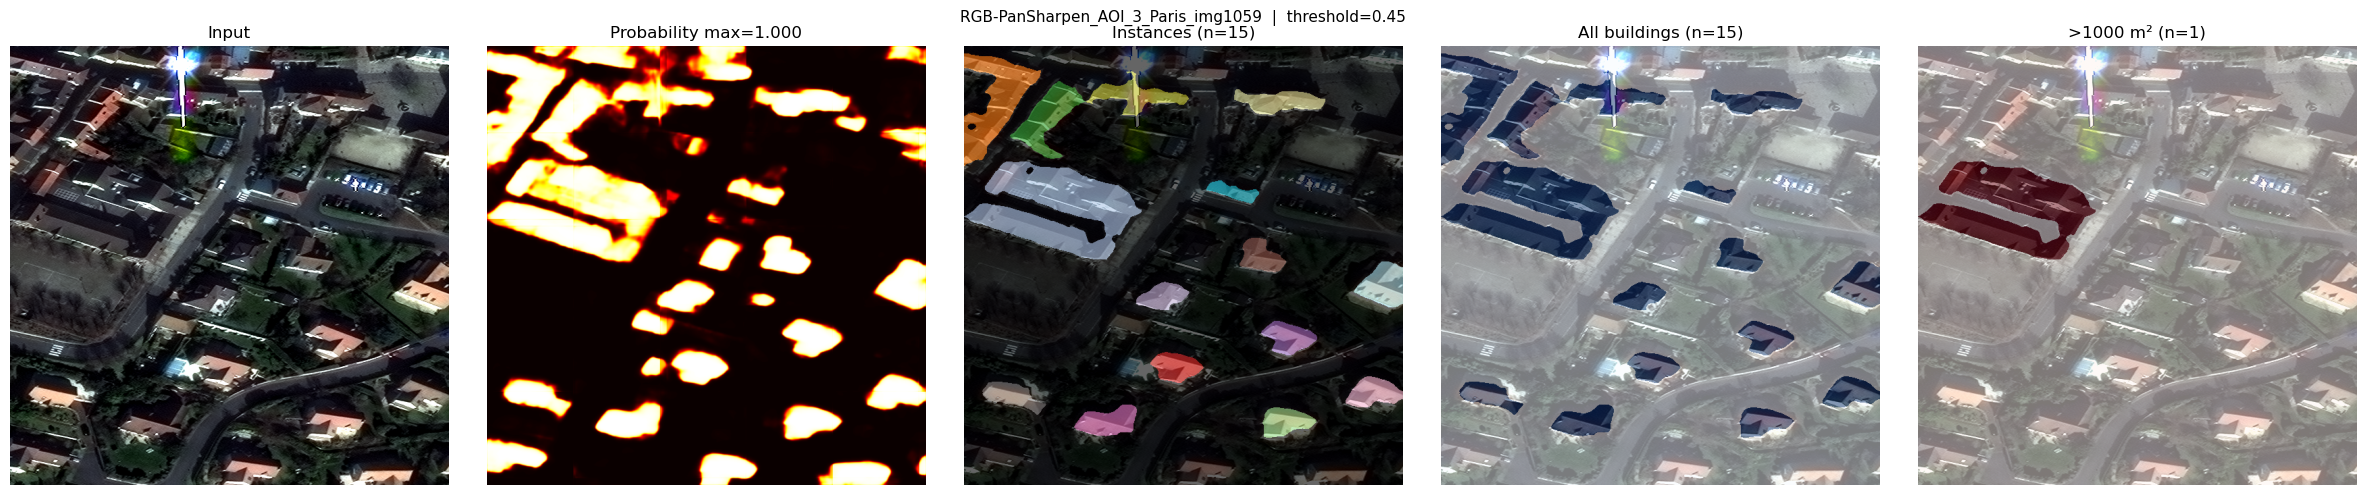

RGB-PanSharpen_AOI_3_Paris_img1059: 15 total | 1 > 1000 m²
  Areas: [1166.1]

Found 1 buildings > 1000 m²
   area_m2
0   1166.1
Saved → predictions/RGB-PanSharpen_AOI_3_Paris_img1059_pred.geojson


In [35]:
OUTPUT_DIR = Path("predictions")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Change this to any GeoTIFF ──────────────────────────────────────
test_img = Path("dataset/AOI_3_Paris_Train/AOI_3_Paris_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_3_Paris_img1059.tif")
# test_img = Path("dataset/AOI_2_Vegas_Train/RGB-PanSharpen/RGB-PanSharpen_AOI_2_Vegas_img1.tif")
gdf = predict_tile(test_img, min_area_m2=1000, threshold=0.45, visualize=True)

print(f"\nFound {len(gdf)} buildings > 1000 m²")
if not gdf.empty:
    print(gdf[["area_m2"]])
    out = OUTPUT_DIR / (test_img.stem + "_pred.geojson")
    gdf.to_file(out, driver="GeoJSON")
    print(f"Saved → {out}")


## 16. Final evaluation — large buildings >1000 m²

Val large masks: 173 total, 0 missing


Evaluating >1000m²: 100%|██████████| 173/173 [01:09<00:00,  2.47it/s]


 FINAL EVALUATION — Large buildings >1000 m²
 Threshold=0.45  Min area=1000m²  Val tiles=173

 PIXEL-LEVEL
  Accuracy  : 99.51%
  Precision : 67.91%
  Recall    : 78.64%
  F1        : 72.88%
  IoU       : 57.33%

 TILE-LEVEL
  Accuracy  : 97.11%
  Precision : 73.33%
  Recall    : 91.67%
  F1        : 81.48%

  TP=11  FP=4  FN=1  TN=157

 Missed tiles : ['RGB-PanSharpen_AOI_3_Paris_img154']
 FP tiles     : ['img360', 'img649', 'img1059', 'img1822']


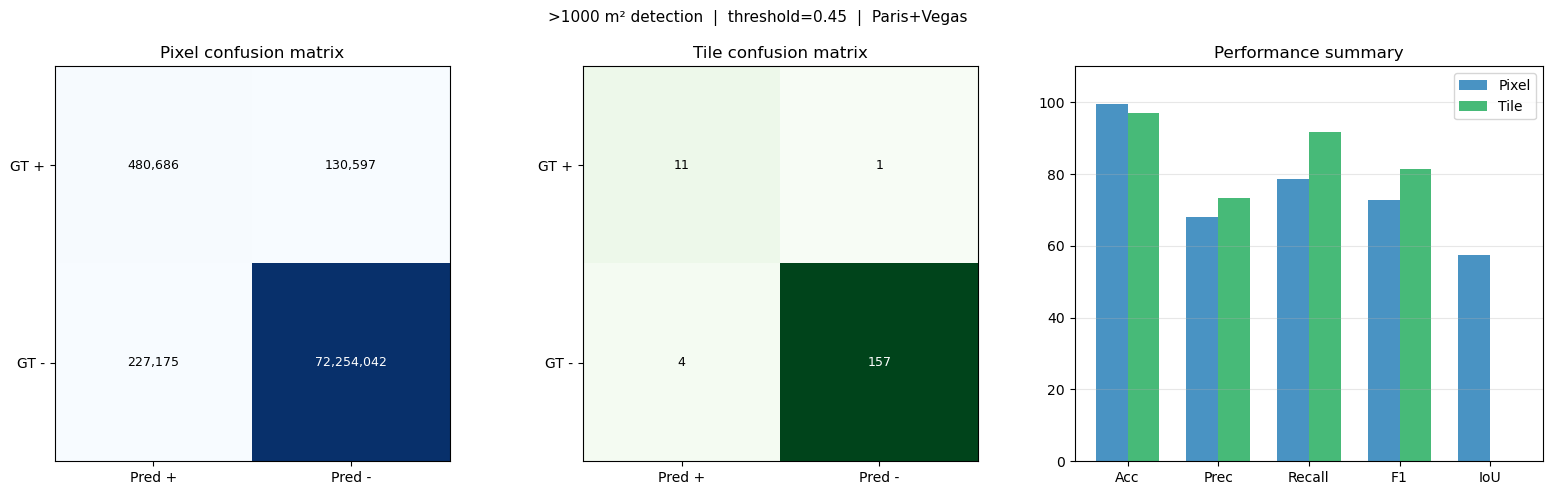

Saved → predictions/final_eval.png


In [36]:
# Build val_masks_large: map each val tile to its large-building GT mask
def get_large_mask_path(all_mask_path):
    """Given a masks_all path, return the corresponding masks/ path."""
    key = all_mask_path.stem.replace("mask_", "")
    # Determine city from path
    if "Paris" in str(all_mask_path):
        return PARIS_MASK_LRG / f"mask_{key}.tif"
    else:
        return VEGAS_MASK_LRG / f"mask_{key}.tif"

val_masks_large = [get_large_mask_path(p) for p in val_masks]

# Confirm they exist
missing = sum(1 for p in val_masks_large if not p.exists())
print(f"Val large masks: {len(val_masks_large)} total, {missing} missing")

px_tp = px_fp = px_fn = px_tn = 0
tile_tp = tile_fp = tile_fn = tile_tn = 0
records = []

for img_path, gt_large_path in tqdm(
        zip(val_imgs, val_masks_large),
        total=len(val_imgs), desc="Evaluating >1000m²"):

    with rasterio.open(gt_large_path) as src:
        gt  = src.read(1).astype(np.float32)
        tf  = src.transform
        crs = src.crs

    gt_has_large = gt.max() == 1
    img          = load_and_normalize(img_path)
    prob         = predict_sliding_window(img, model, device, patch=384, stride=128)

    binary = np.ascontiguousarray((prob > THRESHOLD).astype(np.uint8))
    binary = erosion(binary, disk(3)).astype(np.uint8)
    binary = np.ascontiguousarray(binary)
    h, w   = binary.shape

    # Build predicted large-building mask via area filter
    pred_large_mask = np.zeros((h, w), dtype=np.uint8)
    detected_areas  = []

    for geom_dict, val in shapes(binary, transform=tf):
        if val == 1:
            poly    = shape(geom_dict)
            gdf_tmp = gpd.GeoDataFrame(
                          geometry=[poly], crs=crs
                      ).to_crs("EPSG:32631")
            area_m2 = gdf_tmp.geometry.area.values[0]
            if area_m2 > MIN_AREA_M2 and is_building_shaped(poly):
                detected_areas.append(round(area_m2, 1))
                burned = rasterize(
                    [(poly.__geo_interface__, 1)],
                    out_shape=(h, w), transform=tf,
                    fill=0, dtype=np.uint8)
                pred_large_mask = np.maximum(pred_large_mask, burned)

    pred_has_large = pred_large_mask.max() == 1

    tp = int(((pred_large_mask==1) & (gt==1)).sum())
    fp = int(((pred_large_mask==1) & (gt==0)).sum())
    fn = int(((pred_large_mask==0) & (gt==1)).sum())
    tn = int(((pred_large_mask==0) & (gt==0)).sum())
    px_tp += tp; px_fp += fp; px_fn += fn; px_tn += tn

    if     gt_has_large and     pred_has_large: tile_tp += 1
    elif not gt_has_large and   pred_has_large: tile_fp += 1
    elif   gt_has_large and not pred_has_large: tile_fn += 1
    else:                                       tile_tn += 1

    status = ("TP" if gt_has_large and pred_has_large else
              "FP" if not gt_has_large and pred_has_large else
              "FN" if gt_has_large and not pred_has_large else "TN")
    records.append({"tile": img_path.stem, "status": status,
                    "detected_areas": detected_areas,
                    "px_iou": tp / max(tp+fp+fn, 1)})

def safe_div(a, b): return a / b if b > 0 else 0.0

px_prec = safe_div(px_tp, px_tp+px_fp)
px_rec  = safe_div(px_tp, px_tp+px_fn)
px_f1   = safe_div(2*px_prec*px_rec, px_prec+px_rec)
px_iou  = safe_div(px_tp, px_tp+px_fp+px_fn)
px_acc  = safe_div(px_tp+px_tn, px_tp+px_fp+px_fn+px_tn)
tl_prec = safe_div(tile_tp, tile_tp+tile_fp)
tl_rec  = safe_div(tile_tp, tile_tp+tile_fn)
tl_f1   = safe_div(2*tl_prec*tl_rec, tl_prec+tl_rec)
tl_acc  = safe_div(tile_tp+tile_tn, tile_tp+tile_fp+tile_fn+tile_tn)

print("\n" + "="*55)
print(" FINAL EVALUATION — Large buildings >1000 m²")
print("="*55)
print(f" Threshold={THRESHOLD}  Min area={MIN_AREA_M2}m²  Val tiles={len(val_imgs)}")
print("\n PIXEL-LEVEL")
print(f"  Accuracy  : {px_acc *100:.2f}%")
print(f"  Precision : {px_prec*100:.2f}%")
print(f"  Recall    : {px_rec *100:.2f}%")
print(f"  F1        : {px_f1  *100:.2f}%")
print(f"  IoU       : {px_iou *100:.2f}%")
print("\n TILE-LEVEL")
print(f"  Accuracy  : {tl_acc *100:.2f}%")
print(f"  Precision : {tl_prec*100:.2f}%")
print(f"  Recall    : {tl_rec *100:.2f}%")
print(f"  F1        : {tl_f1  *100:.2f}%")
print(f"\n  TP={tile_tp}  FP={tile_fp}  FN={tile_fn}  TN={tile_tn}")

missed = [r['tile'] for r in records if r['status'] == 'FN']
fps    = [r for r in records if r['status'] == 'FP']
print(f"\n Missed tiles : {missed}")
print(f" FP tiles     : {[r['tile'].split('_')[-1] for r in fps]}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cm, title, cmap in [
    (axes[0], np.array([[px_tp, px_fn],[px_fp, px_tn]]), "Pixel confusion matrix", "Blues"),
    (axes[1], np.array([[tile_tp, tile_fn],[tile_fp, tile_tn]]), "Tile confusion matrix", "Greens"),
]:
    ax.imshow(cm, cmap=cmap)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred +","Pred -"]); ax.set_yticklabels(["GT +","GT -"])
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center", fontsize=9,
                    color="white" if cm[i,j] > cm.max()/2 else "black")

x = np.arange(5); w = 0.35
axes[2].bar(x-w/2, [px_acc*100, px_prec*100, px_rec*100, px_f1*100, px_iou*100],
            w, label="Pixel", color="#2980b9", alpha=0.85)
axes[2].bar(x+w/2, [tl_acc*100, tl_prec*100, tl_rec*100, tl_f1*100, 0],
            w, label="Tile",  color="#27ae60", alpha=0.85)
axes[2].set_xticks(x); axes[2].set_xticklabels(["Acc","Prec","Recall","F1","IoU"])
axes[2].set_ylim(0, 110); axes[2].legend(); axes[2].grid(axis="y", alpha=0.3)
axes[2].set_title("Performance summary")
plt.suptitle(f">1000 m² detection  |  threshold={THRESHOLD}  |  Paris+Vegas", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "final_eval.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → predictions/final_eval.png")


Evaluating: 100%|██████████| 173/173 [01:07<00:00,  2.55it/s]



 FINAL EVALUATION  —  ALL BUILDINGS (UNFILTERED)
 Threshold : 0.45  |  Val tiles : 173

 PIXEL-LEVEL
  Accuracy  : 97.24%
  Precision : 86.79%
  Recall    : 76.35%
  F1        : 81.24%
  IoU       : 68.41%

 TILE-LEVEL
  Accuracy  : 97.69%
  Precision : 97.98%
  Recall    : 97.98%
  F1        : 97.98%

  TP=97  FP=2  FN=2  TN=72


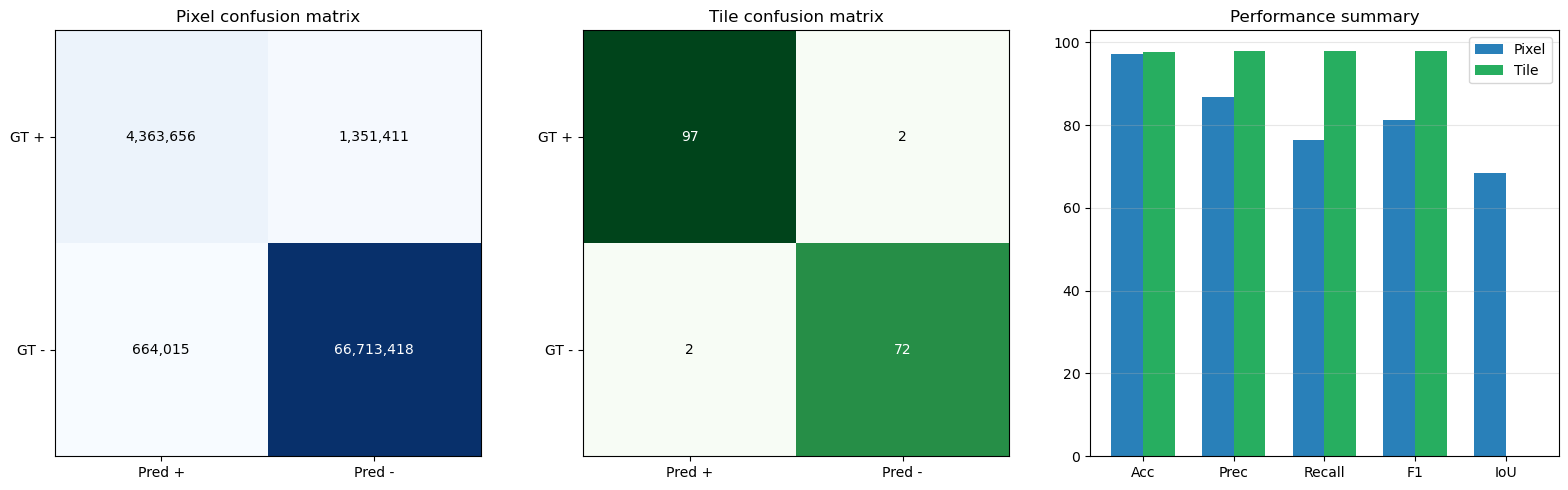

In [37]:
# ─────────────────────────────────────────────
# UNFILTERED EVALUATION (ALL BUILDINGS)
# ─────────────────────────────────────────────

px_tp = px_fp = px_fn = px_tn = 0
tile_tp = tile_fp = tile_fn = tile_tn = 0

records = []

for img_path, gt_path in tqdm(zip(val_imgs, val_masks),
                             total=len(val_imgs), desc="Evaluating"):

    # ── Load ground truth mask ──
    with rasterio.open(gt_path) as src:
        gt  = src.read(1).astype(np.uint8)
        tf  = src.transform
        crs = src.crs

    gt_has = gt.max() == 1   # any building present

    # ── Predict ──
    img  = load_and_normalize(img_path)
    prob = predict_sliding_window(img, model, device,
                                  patch=384, stride=128)

    binary = np.ascontiguousarray((prob > THRESHOLD).astype(np.uint8))
    binary = erosion(binary, disk(3)).astype(np.uint8)
    binary = np.ascontiguousarray(binary)
    h, w   = binary.shape

    # ── Pixel-level confusion ──
    tp = int(((binary==1) & (gt==1)).sum())
    fp = int(((binary==1) & (gt==0)).sum())
    fn = int(((binary==0) & (gt==1)).sum())
    tn = int(((binary==0) & (gt==0)).sum())

    px_tp += tp
    px_fp += fp
    px_fn += fn
    px_tn += tn

    # ── Tile-level confusion ──
    pred_has = binary.max() == 1

    if     gt_has and     pred_has: tile_tp += 1
    elif not gt_has and   pred_has: tile_fp += 1
    elif     gt_has and not pred_has: tile_fn += 1
    else:                           tile_tn += 1

    status = ("TP" if gt_has and pred_has else
              "FP" if not gt_has and pred_has else
              "FN" if gt_has and not pred_has else "TN")

    records.append({
        "tile": img_path.stem,
        "status": status,
        "px_iou": tp / max(tp + fp + fn, 1)
    })

# ── Metrics ──
def safe_div(a, b):
    return a / b if b > 0 else 0.0

px_prec = safe_div(px_tp, px_tp + px_fp)
px_rec  = safe_div(px_tp, px_tp + px_fn)
px_f1   = safe_div(2 * px_prec * px_rec, px_prec + px_rec)
px_iou  = safe_div(px_tp, px_tp + px_fp + px_fn)
px_acc  = safe_div(px_tp + px_tn, px_tp + px_fp + px_fn + px_tn)

tl_prec = safe_div(tile_tp, tile_tp + tile_fp)
tl_rec  = safe_div(tile_tp, tile_tp + tile_fn)
tl_f1   = safe_div(2 * tl_prec * tl_rec, tl_prec + tl_rec)
tl_acc  = safe_div(tile_tp + tile_tn,
                   tile_tp + tile_fp + tile_fn + tile_tn)

# ── Print results ──
print("\n" + "="*55)
print(" FINAL EVALUATION  —  ALL BUILDINGS (UNFILTERED)")
print("="*55)
print(f" Threshold : {THRESHOLD}  |  Val tiles : {len(val_imgs)}")

print("\n PIXEL-LEVEL")
print(f"  Accuracy  : {px_acc *100:.2f}%")
print(f"  Precision : {px_prec*100:.2f}%")
print(f"  Recall    : {px_rec *100:.2f}%")
print(f"  F1        : {px_f1  *100:.2f}%")
print(f"  IoU       : {px_iou *100:.2f}%")

print("\n TILE-LEVEL")
print(f"  Accuracy  : {tl_acc *100:.2f}%")
print(f"  Precision : {tl_prec*100:.2f}%")
print(f"  Recall    : {tl_rec *100:.2f}%")
print(f"  F1        : {tl_f1  *100:.2f}%")

print(f"\n  TP={tile_tp}  FP={tile_fp}  FN={tile_fn}  TN={tile_tn}")

# ── Plot confusion matrices ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cm, title, cmap in [
    (axes[0], np.array([[px_tp, px_fn],[px_fp, px_tn]]),
     "Pixel confusion matrix", "Blues"),
    (axes[1], np.array([[tile_tp, tile_fn],[tile_fp, tile_tn]]),
     "Tile confusion matrix", "Greens"),
]:
    ax.imshow(cm, cmap=cmap)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred +","Pred -"])
    ax.set_yticklabels(["GT +","GT -"])
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}",
                    ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black")

# ── Performance summary ──
x = np.arange(5); w = 0.35

axes[2].bar(x-w/2,
    [px_acc*100, px_prec*100, px_rec*100, px_f1*100, px_iou*100],
    w, label="Pixel", color="#2980b9")

axes[2].bar(x+w/2,
    [tl_acc*100, tl_prec*100, tl_rec*100, tl_f1*100, 0],
    w, label="Tile", color="#27ae60")

axes[2].set_xticks(x)
axes[2].set_xticklabels(["Acc","Prec","Recall","F1","IoU"])
axes[2].legend()
axes[2].grid(axis="y", alpha=0.3)
axes[2].set_title("Performance summary")

plt.tight_layout()
plt.show()